# Transformer Model — Electricity Price Prediction

## 1. Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')

os.makedirs('models', exist_ok=True)

PyTorch: 2.11.0
Device: mps


## 2. Load & Clean Data

In [68]:
# --- Prices ---
df = pd.read_csv('raw_data/combined_energy_price_clean.csv', sep='\t', low_memory=False)
df['Sequence'] = df['Sequence'].astype(str).str.strip()

df_clean = df[((df['AreaDisplayName'] == 'DE-LU') & (df['Sequence'] == '2')) |
              ((df['AreaDisplayName'] == 'DE-AT-LU') & (df['Sequence'] == ''))][['DateTime(UTC)', 'Price[Currency/MWh]']].copy()
df_clean.columns = ['ds', 'y']
df_clean['ds'] = pd.to_datetime(df_clean['ds'])
df_clean = df_clean.dropna().sort_values('ds').reset_index(drop=True)
df_clean = df_clean.set_index('ds').resample('h').mean().reset_index()
df_clean = df_clean.dropna().reset_index(drop=True)

# Cap outliers
df_clean['y'] = df_clean['y'].clip(upper=500)

print(f'Prices: {df_clean.shape}')
print(f'Range: {df_clean["ds"].min()} → {df_clean["ds"].max()}')

Prices: (98974, 2)
Range: 2015-01-04 23:00:00 → 2026-04-21 21:00:00


## 3. Feature Engineering

In [ ]:
df_feat = df_clean.copy()

# --- Temporal features ---
df_feat['hour'] = df_feat['ds'].dt.hour
df_feat['day_of_week'] = df_feat['ds'].dt.dayofweek
df_feat['day_of_year'] = df_feat['ds'].dt.dayofyear
df_feat['month'] = df_feat['ds'].dt.month
df_feat['year'] = df_feat['ds'].dt.year
df_feat['quarter_hour'] = df_feat['ds'].dt.minute // 15

# --- Calendar flags ---
de_holidays = holidays.Germany(years=range(2015, 2027))
df_feat['is_holiday'] = df_feat['ds'].dt.date.apply(lambda x: 1 if x in de_holidays else 0)
df_feat['is_weekend'] = df_feat['ds'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# --- prices Lags over the target ---
df_feat['lag_1h']   = df_feat['y'].shift(1)
df_feat['lag_24h']  = df_feat['y'].shift(24)
df_feat['lag_168h'] = df_feat['y'].shift(168)
df_feat['ma_24h']   = df_feat['y'].rolling(24).mean()
df_feat['ma_168h']  = df_feat['y'].rolling(168).mean()

df_feat = df_feat.dropna().reset_index(drop=True)
print(f'After feature engineering: {df_feat.shape}')

After feature engineering: (98806, 15)


In [70]:
# --- Generation & Consumption ---
df_gen = pd.read_csv('raw_data/final_generation_minimized.csv')
df_gen.columns = ['ds', 'generation', 'consumption']
df_gen['ds'] = pd.to_datetime(df_gen['ds'])
df_gen = df_gen.set_index('ds').resample('h').mean().reset_index()
df_feat = df_feat.merge(df_gen, on='ds', how='left')
df_feat['generation'] = df_feat['generation'].interpolate()
df_feat['consumption'] = df_feat['consumption'].interpolate()

# --- Weather ---
df_weather = pd.read_csv('raw_data/weather_avg.csv')
df_weather['ds'] = pd.to_datetime(df_weather['DateTime(UTC)'])
df_weather = df_weather.drop(columns='DateTime(UTC)').sort_values('ds').reset_index(drop=True)
df_feat = df_feat.merge(df_weather, on='ds', how='left')
weather_cols = ['temperature_c', 'humidity_percent', 'cloud_cover_percent', 'shortwave_radiation_wm2']
df_feat[weather_cols] = df_feat[weather_cols].interpolate()

# --- Wind ---
df_wind = pd.read_csv('raw_data/wind_onshore.csv')
df_wind['ds'] = pd.to_datetime(df_wind['ds'])
df_feat = df_feat.merge(df_wind, on='ds', how='left')
df_feat['wind_onshore'] = df_feat.groupby(df_feat['ds'].dt.hour)['wind_onshore'].transform(
    lambda x: x.fillna(x.mean())
)

print(f'After merging all features: {df_feat.shape}')
print(df_feat.isnull().sum()[df_feat.isnull().sum() > 0])

# --- Net Generation + lags ---
# df_feat['net_generation'] = df_feat['generation'] - df_feat['consumption']

# df_feat['netgen_lag_1']        = df_feat['net_generation'].shift(1)
# df_feat['netgen_lag_4']        = df_feat['net_generation'].shift(4)
# df_feat['netgen_lag_24']       = df_feat['net_generation'].shift(24)
# df_feat['netgen_roll_mean_4']  = df_feat['net_generation'].rolling(4).mean()
# df_feat['netgen_roll_mean_24'] = df_feat['net_generation'].rolling(24).mean()
# df_feat['netgen_roll_std_4']   = df_feat['net_generation'].rolling(4).std()
# df_feat['netgen_roll_std_24']  = df_feat['net_generation'].rolling(24).std()

df_feat = df_feat.dropna().reset_index(drop=True)
print(f'After net_generation features: {df_feat.shape}')

After merging all features: (98806, 22)
Series([], dtype: int64)
After net_generation features: (98806, 22)


In [71]:
df_feat.columns

Index(['ds', 'y', 'hour', 'day_of_week', 'day_of_year', 'month', 'year',
       'quarter_hour', 'is_holiday', 'is_weekend', 'lag_1h', 'lag_24h',
       'lag_168h', 'ma_24h', 'ma_168h', 'generation', 'consumption',
       'temperature_c', 'humidity_percent', 'cloud_cover_percent',
       'shortwave_radiation_wm2', 'wind_onshore'],
      dtype='object')

## 4. Scaling

In [ ]:
df_feat['target'] = df_feat['y'].shift(-24)
df_feat = df_feat.dropna().reset_index(drop=True)


# Pirce also separated
scaler_price = MinMaxScaler()
df_feat['y_scaled'] = scaler_price.fit_transform(df_feat[['y']])

df_feat['target_scaled'] = scaler_price.transform(df_feat[['target']].values.reshape(-1, 1))

# the rest together
other_cols = ['hour', 'day_of_week', 'day_of_year', 'month', 'year',
              'lag_1h', 'lag_24h', 'lag_168h', 'ma_24h', 'ma_168h',
              'generation', 'consumption', 'temperature_c', 'humidity_percent',
              'cloud_cover_percent', 'shortwave_radiation_wm2',
              'is_holiday', 'is_weekend', 'wind_onshore']

scaler_other = MinMaxScaler()
df_feat[other_cols] = scaler_other.fit_transform(df_feat[other_cols])

feature_cols = ['y_scaled'] + other_cols
print(f'Total features: {len(feature_cols)}')

Total features: 20


/Users/javierinocentezabala/.pyenv/versions/3.10.6/envs/grid-intelligence/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


## 5. Sequences & Split

In [85]:
# Escalar target igual que el precio
def create_sequences(data, target, seq_len=24):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(target[i+seq_len])
    return np.array(X), np.array(y)

values = df_feat[feature_cols].values
target = df_feat['target_scaled'].values  # escalado

X, y = create_sequences(values, target, seq_len=24)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = torch.FloatTensor(X_train).to(device)
X_test  = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).to(device)
y_test  = torch.FloatTensor(y_test).to(device)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: torch.Size([78968, 24, 20]) | X_test: torch.Size([19742, 24, 20])


## 6. Model

In [86]:
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x.squeeze(-1)

n_features = len(feature_cols)
model = TransformerModel(input_size=n_features).to(device)
print(f'Model ready — {n_features} input features')

Model ready — 20 input features


## 7. Training (with checkpoint)

if the model exist will take it from the cache

In [87]:
MODEL_PATH = 'models/transformer_best_v2.pth'

n_features = len(feature_cols)  # 29
model = TransformerModel(input_size=n_features).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

epochs = 50
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), MODEL_PATH)

print(f'Mejor loss: {best_loss:.6f}')

Epoch 10/50 — Loss: 0.001660
Epoch 20/50 — Loss: 0.001126
Epoch 30/50 — Loss: 0.000750
Epoch 40/50 — Loss: 0.000553
Epoch 50/50 — Loss: 0.000433
Mejor loss: 0.000431


## 8. Evaluation

In [88]:
model.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test), 1000):
        batch = X_test[i:i+1000]
        preds.append(model(batch).cpu().numpy())

y_pred_np = np.concatenate(preds)
y_test_np = y_test.cpu().numpy()

y_pred_real = scaler_price.inverse_transform(y_pred_np.reshape(-1, 1)).flatten()
y_test_real = scaler_price.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')

MAE:  26.41 EUR/MWh
RMSE: 36.55 EUR/MWh


## 9. Forecast vs Actual

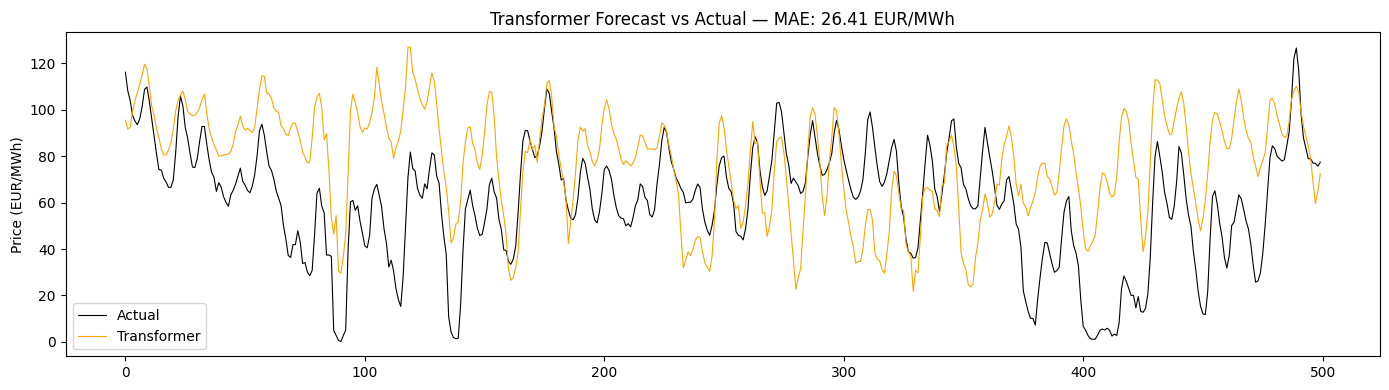

In [89]:
plt.figure(figsize=(14, 4))
plt.plot(y_test_real[:500], label='Actual', color='black', linewidth=0.8)
plt.plot(y_pred_real[:500], label='Transformer', color='orange', linewidth=0.8)
plt.title(f'Transformer Forecast vs Actual — MAE: {mae:.2f} EUR/MWh')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.tight_layout()
plt.show()

# Model with keras

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

n_features = len(feature_cols)
inputs = keras.Input(shape=(24, n_features))
x = keras.layers.Dense(128)(inputs)  # input projection más grande
x = keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
x = keras.layers.LayerNormalization()(x)
x = keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
x = keras.layers.LayerNormalization()(x)
x = keras.layers.MultiHeadAttention(num_heads=8, key_dim=64)(x, x)  # 3ra capa
x = keras.layers.LayerNormalization()(x)
x = keras.layers.GlobalAveragePooling1D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(128, activation='relu')(x)
x = keras.layers.Dropout(0.1)(x)
x = keras.layers.Dense(64, activation='relu')(x)
outputs = keras.layers.Dense(1)(x)

model_keras = keras.Model(inputs=inputs, outputs=outputs)
model_keras.compile(optimizer=keras.optimizers.Adam(0.0001), loss='mse')
model_keras.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 24, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 24, 128)   │      2,688 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │    263,808 │ dense_22[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 128)   │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 256)       │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │     32,896 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │      8,256 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │         65 │ dense_25[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 869,121 (3.32 MB)

 Trainable params: 869,121 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
X_train_np = X_train.cpu().numpy()
X_test_np  = X_test.cpu().numpy()
y_train_np = y_train.cpu().numpy()
y_test_np  = y_test.cpu().numpy()

callbacks = [
    ModelCheckpoint('models/keras_best.keras', save_best_only=True, monitor='val_loss'),
    EarlyStopping(patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5)
]

history = model_keras.fit(
    X_train_np, y_train_np,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 42s 141ms/step - loss: 1.2381 - val_loss: 0.0511 - learning_rate: 1.0000e-04
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - loss: 1.2189 - val_loss: 0.0332 - learning_rate: 1.0000e-04
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - loss: 0.4371 - val_loss: 0.0029 - learning_rate: 1.0000e-04
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - loss: 0.0651 - val_loss: 0.0026 - learning_rate: 1.0000e-04
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - loss: 0.0302 - val_loss: 0.0050 - learning_rate: 1.0000e-04
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - loss: 0.1125 - val_loss: 0.0154 - learning_rate: 1.0000e-04
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - loss: 0.7105 - val_loss: 8.7543 - learning_rate: 1.0000e-04
Epoch 8/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 36s 131ms/step - loss: 0.5515 - val_loss: 0.1436 - learning_rate: 1.0000e-04
Epoch 9/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - loss: 0

In [29]:
# Eval
y_pred_np = model_keras.predict(X_test_np).flatten()

y_pred_real = scaler_price.inverse_transform(y_pred_np.reshape(-1, 1)).flatten()
y_test_real = scaler_price.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')

618/618 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step
MAE:  32.73 EUR/MWh
RMSE: 43.89 EUR/MWh


Regreitfully Keras is not retriving the best result

# LSTM

In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

model_lstm = LSTMModel(input_size=n_features).to(device)
print(f'params: {sum(p.numel() for p in model_lstm.parameters()):,}')

params: 55,361


In [36]:
MODEL_PATH = 'models/lstm_best.pth'

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

epochs = 50
best_loss = float('inf')

for epoch in range(epochs):
    model_lstm.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_lstm(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model_lstm.state_dict(), MODEL_PATH)

print(f'Mejor loss: {best_loss:.6f}')

Epoch 10/50 — Loss: 0.000564
Epoch 20/50 — Loss: 0.000420
Epoch 30/50 — Loss: 0.000339
Epoch 40/50 — Loss: 0.000309
Epoch 50/50 — Loss: 0.000274
Mejor loss: 0.000274


In [34]:
model_lstm.eval()
preds = []
with torch.no_grad():
    for i in range(0, len(X_test), 1000):
        batch = X_test[i:i+1000]
        preds.append(model_lstm(batch).cpu().numpy())

y_pred_np = np.concatenate(preds)
y_test_np = y_test.cpu().numpy()

y_pred_real = scaler_price.inverse_transform(y_pred_np.reshape(-1, 1)).flatten()
y_test_real = scaler_price.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f'MAE:  {mae:.2f} EUR/MWh')
print(f'RMSE: {rmse:.2f} EUR/MWh')

MAE:  53.66 EUR/MWh
RMSE: 61.56 EUR/MWh
